# Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.

- is increased/decreased the slower/faster the lander is moving.

- is decreased the more the lander is tilted (angle not horizontal).

- is increased by 10 points for each leg that is in contact with the ground.

- is decreased by 0.03 points each frame a side engine is firing.

- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.


You can read more the LunarLander environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![LunarLander](https://gymnasium.farama.org/_images/lunar_lander.gif)

# Deep Q-Learning (T2, T3)

The main idea behind Q-learning is that if we had a function $Q^*:\text{State}\times\text{Action}\to\mathbb{R}$ that could tell us what our return would be if we were to take an action in a given state, then we could easily construct a policy that maximizes our rewards:
$$
\pi^*(s)=\arg\max_a\,Q^*(s,a). \tag{1}
$$
But this is not scalable. We would need to compute $Q(s,a)$ for every state–action pair. If the state is, e.g., raw pixels of a game screen, it is computationally infeasible to cover the entire state space. Since neural networks are universal function approximators, we can create one and train it to resemble $Q^*$.

For our training update rule, every $Q$ function for a policy $\pi$ obeys the (policy) Bellman equation (expectations made explicit):
$$
Q^{\pi}(s,a)=\mathbb{E}_{\,s'\sim P(\cdot\mid s,a)}\!\Big[r(s,a)+\gamma\,\mathbb{E}_{\,a'\sim\pi(\cdot\mid s')}\big[Q^{\pi}(s',a')\big]\Big]. \tag{2}
$$

In DQN (off-policy), we use the optimal Bellman target (with a max over actions). The temporal-difference error $\delta$ is:
$$
\delta \;=\; Q(s,a;\theta)\;-\;\Big(r(s,a)\;+\;\gamma\,\max_{a'} Q_{\text{target}}(s',a')\Big). \tag{3}
$$

To minimise this error, we use the [Huber loss](https://en.wikipedia.org/wiki/Huber_loss), computed over a minibatch $B$ sampled from replay memory:
$$
\mathcal{L}(\theta)=\frac{1}{|B|}\sum_{(s,a,r,s')\in B}\,\mathcal{L}_{\text{Huber}}\!\big(\delta\big). \tag{4}
$$

$$
\mathcal{L}_{\text{Huber}}(\delta)=
\begin{cases}
\dfrac{1}{2}\,\delta^2, & \text{if } |\delta|\le 1,\\[4pt]
|\delta|-\dfrac{1}{2}, & \text{otherwise.}
\end{cases} \tag{5}
$$


In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 48.9 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple
from itertools import count
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

In [ ]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Create the environment
env = gym.make("LunarLander-v3")

### Experience Replay (T2,T3)

While using a memory buffer is possible and useful in Q-Learning, it becomes fundamental in Deep Q-Learning. The neural network which we use to approximate the Q-value function needs varied data. If we use data from each successive step of the simulation, these frames are correlated with each other and will nudge the weights of the model toward a certain specific situation, "forgetting" the other possible scenarios rather quickly. For example, if for 100 successive frames the lander is in a situation which differs only slightly frame to frame, with the lander tilted to the right and the right engine active, it may overfit this condition and quickly forget how to behave correctly in the opposite case. Another big problem with correlated data is that in certain situations the math may become unstable, with some of the weights diverging due to the similarity of a set of frames.

Another reason to use a memory buffer is computational efficiency. Re-using the same data in different batches instead of throwing them out after having used them once for training takes more out of the same material. Also, using a batch of data instead of sequential frames allows for parallelization of the training process which can take advantage of GPUs architecture.

The process of creating a storage of past data and using batches from it for training is called Experience Replay.

In [ ]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward', 'done'))

class ReplayMemory:
    def __init__(self, capacity): #We need a maximum capacity to overcome RAM limits
        self.memory = []
        self.capacity = capacity
        self.position = 0

    def push(self, *args):
        if len(self.memory) < self.capacity:
            self.memory.append(None)                   #We append None to extend the list until capacity
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity #When the capacity is full, we substitute the oldest sample with a new one

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### Q-Network (T1)

The Q-Network we want to build needs to have an input dimension identical to the dimension of the state vectors. We have three coordinates $(x,y,θ)$ and the corrisponding linear and angular velocities $(̇̇\dot{x}, \dot{y}, \dot{θ})$, plus two booleans which are indicators of whether each leg of the lunar lender is touching the ground. Therefore each state is described by 8 variables and the Q-Network needs to accept an 8-dimensional input.

The output dimension needs to equal the action space dimension. This environment allows 4 actions, 0 : do nothing, 1 : fire left orientation engine, 2 : fire main engine, 3 : fire right orientation engine. Therefore, the network needs to map the input to a 4 dimensional vector containing the 4 actions' approximated qvalues.

In [ ]:
print(f"The action space is {env.action_space}\n")
print(f"The observation space is {env.observation_space}")

The action space is Discrete(4)

The observation space is Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


In [ ]:
n_actions = env.action_space.n
n_observations = env.observation_space.shape[0]

The Lunar Lender environment, while more complicated than the Frozen Lake environment used in the previous exercises, doesn't need very complicated architectures to obtain working approximations. A Multi-Layer Perceptron may just do the trick.

We use an Input Layer which maps the 8 input values to 128 neurons (128x8 weights + 128 bias = 896 parameters) through the Rectified Linear Unit $f(x) = max(0,x)$. Another layer does the same with dimension 128x128. Finally the output layer collects the values into 4 categories. We don't need any softmax function because we are trying to approximate the qvalues directly.

In [ ]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

### Exploration vs Exploitation

Notice that Q-learning only learns about the states and actions it visits. What if an optimal state remains unvisited due to not being explored? The agent should sometimes pick suboptimal actions in order to visit new states and actions. <br>

A simple strategy is to use an $\epsilon$-greedy policy. According to this policy, the agent takes a random action with epsilon probability. The value of epsilon is high at the start of training and low towards the end. So, the agent explores more at the start and then exploit the learned policy more at the end.

### Hyperparameters (T2, T3)

As in any RL algorithm, also in this case we have different hyperparameters. We have a learning rate for the neural network. We have a capacity which determines how many steps to keep in the memory buffer. There is the size of each batch used for training, in a power of 2 to align with the MLP definition. target_freq refers to the number of steps after which we re-align the target network to the policy network.

We also gave the gamma value, the discount factor from the temporal difference error definition, and the parameters for the epsilon-greedy policy. In this kind of task where we have many steps, often hundreds, before the lander fails or succeds the landing, having a farsighted algorithm is particularly important and therefore we select a .99 gamma. This means that a reward obtained after about 100 steps is still quite important ($γ^{100} = 0.99^{100} \approx 0.366$, so about 37% of the original value) to the agent for the current step.

The training time in this case is quite long, therefore only a few set of parameters, selected manually, were used. A few trials were made with the capacity value, going from 1000 to 5000 to 10000. An higher capacity seems to correlated with better performances, as the model has more examples from the past to work with at any time. A too high learning rate of about 1e-3 produced unstable results, and a too high decay rate also produced bad results, likely because the model didn't have enough time to explore.

In [ ]:
learning_rate = 5e-5
target_freq = 500 #Every target_freq steps, we copy the policy weights

total_episodes=600
capacity = 10000
batch_size = 128

gamma = 0.99
epsilon_0 = 1
epsilon_min = 0.05
decay_rate = 2000

### Training

The training process makes use of two networks. The so called policy network is the one actually used to select the best action given a state. It's weights are updated on the base of the Huber Loss at each step. The other network is called the target network. It is a copy of the policy network, but is not updated at each step but kept frozen for a certain interval (for example 2000 steps). This target network is used to offer the policy network a fixed target to aim for; we don't want it to move constantly but to be updated slowly to allow the policy target weights to stabilize.

In [ ]:
def optimize_model():
    if len(memory) < batch_size: #We want to wait until we have enough data to make a batch
        return

    transitions = memory.sample(batch_size)
    batch = Transition(*zip(*transitions)) #Create the state, action, next state, ... vectors

    state_batch = torch.cat(batch.state)   #Concatanate the values into a batch
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    next_state_batch = torch.cat(batch.next_state)
    done_batch = torch.cat(batch.done)

    state_action_values = policy_net(state_batch).gather(1, action_batch) #qvalues from the policy network to select the best action

    with torch.no_grad():
        next_state_values = target_net(next_state_batch).max(1)[0] #qvalues from the target network for the next state

    expected_state_action_values = reward_batch + (gamma*next_state_values*(1 - done_batch)) #Target

    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1)) #Huber Loss

    optimizer.zero_grad() #Reset the gradient values
    loss.backward() #Backpropagate
    optimizer.step() #Update the policy network weights

In [ ]:
policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=learning_rate, amsgrad=True) #amsgrad keeps track of very high gradient values like those
                                                                                 #from a succesfull landing, which could be otherwise lost from a series
                                                                                 #of small changes.
memory = ReplayMemory(capacity=capacity)

episode_rewards = []
steps_done = 0

for episode in range(total_episodes):
    obs, info = env.reset()
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0

    for t in count():
        #epsilon-greedy strategy with decay rate
        epsilon = epsilon_min + (epsilon_0 - epsilon_min)*math.exp(-1.*steps_done/decay_rate)
        steps_done += 1

        if random.random() > epsilon:
            with torch.no_grad():
                action = policy_net(state).max(1)[1].view(1, 1)
        else:
            action = torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

        #Step
        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        total_reward += reward
        reward = torch.tensor([reward], device=device)
        done_flag = torch.tensor([float(terminated)], device=device) #Is the task terminated?
        next_state = torch.tensor(next_obs, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, next_state, reward, done_flag)
        state = next_state

        optimize_model()

        #Update the Target Network
        if steps_done % target_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if done:
          episode_rewards.append(total_reward)
          break

# Visualization (T4)

After 600 episodes (Training Time: 24 minutes) and with a bit of manual play on the parameters, we achieved a network able to approximate a good enough qvalue function. The moving average shows performances improving with the episodes and reaching a plateau with an average above the threshold considered a success in the Lunar Lander environment (200 of episode reward). The variability of the results is lower than at the beginning of training but still present, with some runs not able to go above the threshold. The results are positive but certainly not perfect.

The training shows a very fast pace of improvement over about the first 100 episodes, which slowes afterward until about episode 300. The results variance is still high, and the networks seems to show some amount of forgetting, with the moving average decreasing at a certain point. The Lunar Lander environment is putting the simple architecture we are using under stress. Perhaps more hidden layers and a longer training would offer more stable policies and results.

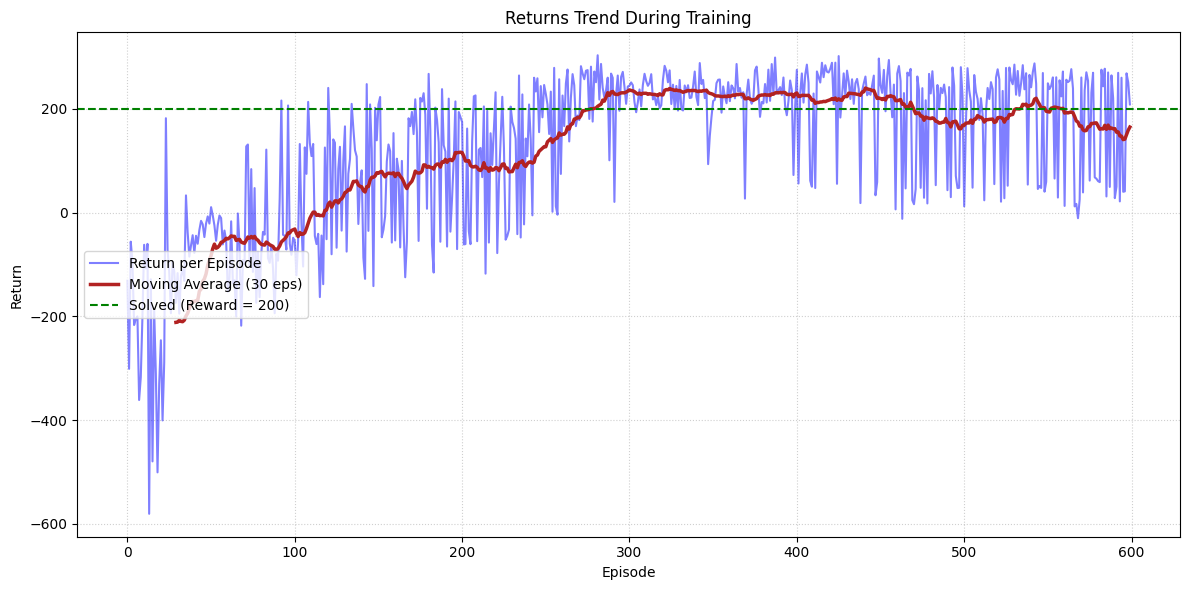

In [ ]:
def plot(returns):
    plt.figure(figsize=(12, 6))

    plt.plot(returns, label='Return per Episode', color='blue', alpha=0.5)

    window_size = 30
    if len(returns) >= window_size:
        moving_avg = np.convolve(returns, np.ones(window_size)/window_size, mode='valid')
        x_axis = np.arange(window_size - 1, len(returns))
        plt.plot(x_axis, moving_avg, label=f'Moving Average ({window_size} eps)',
                 color='firebrick', linewidth=2.5)

    #THe Lunar Lander environment is considered solver if the episode reward si above 200, so we add a threshold
    plt.axhline(y=200, color='green', linestyle='--', label='Solved (Reward = 200)')

    plt.title('Returns Trend During Training')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.legend(loc='center left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot(episode_rewards)

In [ ]:
evaluation_episodes = 100
evaluation_rewards = []
max_steps = 50

for episode in range(evaluation_episodes):
    obs, info = env.reset()
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    total_rewards = 0.0

    for _ in range(max_steps):
        with torch.no_grad():
            action = policy_net(state).max(1)[1].view(1, 1)

        obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        total_rewards += reward

        state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        if done:
            break

    evaluation_rewards.append(total_rewards)

mean_reward = float(np.mean(evaluation_rewards))
std_reward = float(np.std(evaluation_rewards))
print(f"Mean reward over {evaluation_episodes} episodes: {mean_reward:.2f}")
print(f"Std of rewards over {evaluation_episodes} episodes: {std_reward:.2f}")


Mean reward over 100 episodes: 22.48
Std of rewards over 100 episodes: 25.72
